# B4T1 - Diseño de Redes Confiables
## Parte 4: Incertidumbre

Implementación de un **modelo auxiliar de incertidumbre** que estima el error esperado del clasificador principal.

Primero, el modelo final genera una probabilidad:

$$
\hat{y}*i = f*{\theta}(x_i)
$$

Después se calcula su error real:

$$
e_i = |y_i-\hat{y}_i|
$$

El modelo auxiliar aprende a predecir ese error:

$$
\hat{u}*i = g*{\phi}(x_i,\hat{y}_i)
$$

donde $\hat{u}_i$ representa la incertidumbre estimada. Una incertidumbre alta indica que el modelo principal puede ser menos fiable para ese solicitante.

La salida final incluye:

$$
(\text{clase predicha},\ \text{probabilidad},\ \text{incertidumbre})
$$

Se compara la distribución de incertidumbre entre los usuarios clasificados como **buenos pagadores** y **malos pagadores**, y se analiza si aumenta cuando las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` contienen valores ausentes o imputados.

> **Reutilización**: se utiliza el modelo final obtenido en el apartado 3. No se vuelve a entrenar ni a optimizar su arquitectura; únicamente se generan sus predicciones y errores para entrenar el modelo auxiliar de incertidumbre.


# 1. Imports

In [2]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.base import (
    load_home_credit_data,
    build_model_from_config,
    compute_class_weight_balanced,
    FEATURE_NAMES,
)

from src.fair import (
    stack_target_sensitive,
    make_fair_loss,
    FairCorr,
    TargetAUC,
    evaluate_binary_predictions,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_PATH = os.path.join(ROOT, "data", "application_train.csv")
OUTPUTS = os.path.join(ROOT, "outputs")
os.makedirs(OUTPUTS, exist_ok=True)

# 2. Datos para el entrenamiento 

In [3]:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data(DATA_PATH)

X_fit, X_cal, y_fit, y_cal, s_fit, s_cal = train_test_split(
    X_train,
    y_train,
    s_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train,
)

y_fit2 = stack_target_sensitive(y_fit, s_fit)
y_cal2 = stack_target_sensitive(y_cal, s_cal)

cw = compute_class_weight_balanced(y_fit)
W_NEG, W_POS = cw[0], cw[1]

print("X_fit:", X_fit.shape)
print("X_cal:", X_cal.shape)
print("X_test:", X_test.shape)
print("y_fit2:", y_fit2.shape, " -> [target, sensible]")
print(f"class_weight -> neg={W_NEG:.3f} | pos={W_POS:.3f}")
print("Features:", FEATURE_NAMES)

X_fit: (209104, 11)
X_cal: (36901, 11)
X_test: (61502, 11)
y_fit2: (209104, 2)  -> [target, sensible]
class_weight -> neg=0.544 | pos=6.193
Features: ['CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_NULL', 'EXT_SOURCE_2_NULL', 'EXT_SOURCE_3_NULL']


# 3. Modelo Keras-tuner

El modelo final que se utiliza en esta parte es el resultado de combinar lo trabajado en los tres apartados anteriores. En concreto, se construye a partir de la **topología seleccionada con Keras Tuner**, manteniendo la arquitectura `32-64-32` con activación `relu` y los valores de `dropout` óptimos encontrados en la búsqueda.

Sobre esa topología se incorpora la **capa customizada** diseñada en el apartado 1, que introduce la señal de ratio de endeudamiento dentro de la red, y se entrena con la **función de coste customizada de aprendizaje justo** desarrollada en el apartado 2. En este caso se utiliza `BEST_FAIR_LAMBDA = 0.5`, que fue el valor elegido como mejor compromiso entre rendimiento predictivo y equidad.

Por tanto, este modelo final no es una red nueva independiente, sino la integración de:
- la **arquitectura optimizada** del apartado 3,
- la **capa custom** del apartado 1,
- y la **FAIR loss** del apartado 2.

Este es el modelo principal sobre el que después se construye el análisis de incertidumbre.

In [4]:
BEST_TOPOLOGY = {
    "hidden_units": [32, 64, 32],
    "dropouts": [0.1, 0.2, 0.0],
    "activation": "relu",
    "learning_rate": 1e-2,
}

BEST_FAIR_LAMBDA = 0.5
# Si quieres clavar el trial de la imagen, usa:
# BEST_FAIR_LAMBDA = 0.01

keras.utils.set_random_seed(SEED)

final_model = build_model_from_config(
    input_dim=X_fit.shape[1],
    hidden_units=BEST_TOPOLOGY["hidden_units"],
    dropouts=BEST_TOPOLOGY["dropouts"],
    activation=BEST_TOPOLOGY["activation"],
    use_custom_layer=True,
    output_activation="sigmoid",
    output_name="pd",
    name="fair_final_model",
)

final_model.summary()

Model: "fair_final_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ratio_endeudamiento             │ (None, 12)             │             0 │
│ (RatioEndeudamientoLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pd (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Entrenamiento del modelo 


Epoch 1/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - auc: 0.7135 - fair_corr: 0.0040 - loss: 0.6471 - val_auc: 0.7230 - val_fair_corr: 0.0516 - val_loss: 0.6449
Epoch 2/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.7222 - fair_corr: 0.0011 - loss: 0.6359 - val_auc: 0.7250 - val_fair_corr: 0.0326 - val_loss: 0.6395
Epoch 3/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.7237 - fair_corr: 0.0029 - loss: 0.6346 - val_auc: 0.7260 - val_fair_corr: 0.0394 - val_loss: 0.6413
Epoch 4/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7244 - fair_corr: 0.0027 - loss: 0.6337 - val_auc: 0.7244 - val_fair_corr: 0.0193 - val_loss: 0.6402
Epoch 5/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.7247 - fair_corr: 0.0036 - loss: 0.6330 - val_auc: 0.7269 - val_fair_corr: 0.0336 - val_loss: 0.6386
Epoch 6/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.7258 - fair_corr: 0.0027 - loss: 0.6321 - val_auc: 0.7271 - val_fair_corr: 0.0253 - val_loss: 0.6380
Epoch 7/40
409/409 ━━━━━━━━

,auc,fair_corr,loss,val_auc,val_fair_corr,val_loss
18,0.729508,0.003481,0.627906,0.729388,0.022668,0.633559
19,0.728685,0.004496,0.628522,0.728871,0.017978,0.635181
20,0.729457,0.003252,0.628841,0.728675,0.033384,0.636756
21,0.728216,0.004293,0.628501,0.728290,0.019434,0.635279
22,0.728904,0.003539,0.627956,0.729009,0.017676,0.635726


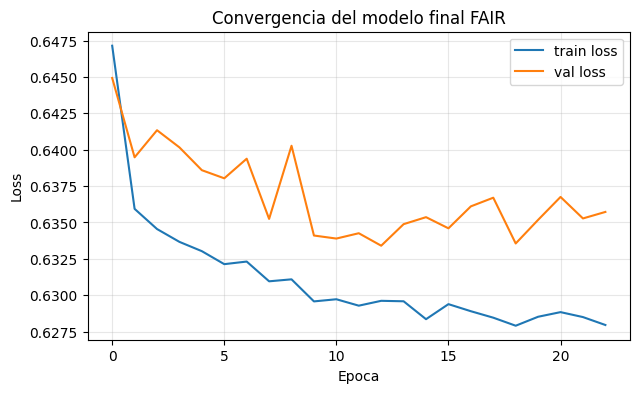

In [5]:
keras.backend.clear_session()

final_model.compile(
    optimizer=keras.optimizers.Adam(BEST_TOPOLOGY["learning_rate"]),
    loss=make_fair_loss(BEST_FAIR_LAMBDA, base_error="bce", w_neg=W_NEG, w_pos=W_POS),
    metrics=[TargetAUC(name="auc"), FairCorr()],
)

es_final = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history_final = final_model.fit(
    X_fit,
    y_fit2,
    validation_data=(X_cal, y_cal2),
    epochs=40,
    batch_size=512,
    verbose=1,
    callbacks=[es_final],
)

hist_final_df = pd.DataFrame(history_final.history)
display(hist_final_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(history_final.history["loss"], label="train loss")
plt.plot(history_final.history["val_loss"], label="val loss")
plt.title("Convergencia del modelo final FAIR")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 5. Celda de predicciones y errores del modelo

In [6]:
p_cal = final_model.predict(X_cal, verbose=0, batch_size=4096).ravel()
p_test = final_model.predict(X_test, verbose=0, batch_size=4096).ravel()

metricas_test = evaluate_binary_predictions(y_test, p_test, s=s_test)
display(pd.DataFrame([metricas_test]).round(4))

# Error absoluto real del modelo principal
cal_abs_error = np.abs(np.asarray(y_cal).astype("float32") - p_cal).reshape(-1, 1)
test_abs_error = np.abs(np.asarray(y_test).astype("float32") - p_test)

# Añadimos la prediccion p_hat como feature extra para el modelo de incertidumbre
X_cal_unc = np.column_stack([X_cal, p_cal]).astype("float32")
X_test_unc = np.column_stack([X_test, p_test]).astype("float32")

preds_test = pd.DataFrame({
    "y_true": np.asarray(y_test).astype(int),
    "pd_hat": p_test,
    "y_hat": (p_test >= 0.5).astype(int),
    "error_abs_real": test_abs_error,
})

display(preds_test.head())

,accuracy,roc_auc,pr_auc,fair_corr,dpd
0,0.6558,0.7314,0.2087,0.0183,0.0173


,y_true,pd_hat,y_hat,error_abs_real
0,0,0.342625,0,0.342625
1,0,0.330096,0,0.330096
2,0,0.439975,0,0.439975
3,0,0.361697,0,0.361697
4,0,0.613037,1,0.613037


# 6. Modelo auxiliar de incertidumbre

Para estimar la incertidumbre de las predicciones, se ha construido un **segundo modelo auxiliar** independiente del modelo principal. La idea es sencilla: el primer modelo se encarga de predecir la probabilidad de impago, mientras que este segundo modelo aprende a estimar **cuánto puede equivocarse** el primero en cada observación.

De esta forma, el sistema final no solo devuelve una **clase predicha**, sino también una **medida de incertidumbre** asociada a esa predicción. Así, las observaciones con mayor incertidumbre pueden interpretarse como casos más dudosos o menos fiables, y por tanto candidatos a una revisión más cuidadosa.

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0170 - mae: 0.0973 - val_loss: 0.0084 - val_mae: 0.0583
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0094 - mae: 0.0636 - val_loss: 0.0078 - val_mae: 0.0508
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0087 - mae: 0.0582 - val_loss: 0.0075 - val_mae: 0.0485
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0083 - mae: 0.0552 - val_loss: 0.0074 - val_mae: 0.0478
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0081 - mae: 0.0533 - val_loss: 0.0074 - val_mae: 0.0471
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0079 - mae: 0.0515 - val_loss: 0.0073 - val_mae: 0.0464
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0078 - mae: 0.0504 - val_loss: 0.0073 - val_mae: 0.0475
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077 - mae: 0.0493 - val_loss: 0.0073 - val_mae: 0.0465
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

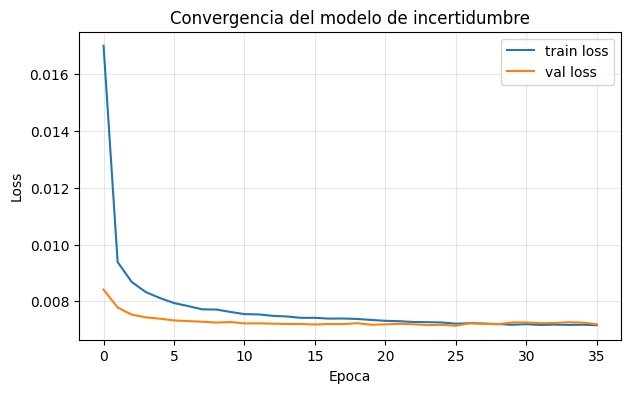

In [7]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

uncertainty_model = build_model_from_config(
    input_dim=X_cal_unc.shape[1],
    hidden_units=BEST_TOPOLOGY["hidden_units"],
    dropouts=BEST_TOPOLOGY["dropouts"],
    activation=BEST_TOPOLOGY["activation"],
    use_custom_layer=True,
    output_activation="sigmoid",
    output_name="error_abs_hat",
    name="uncertainty_model",
)

uncertainty_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
)

es_unc = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history_unc = uncertainty_model.fit(
    X_cal_unc,
    cal_abs_error,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    verbose=1,
    callbacks=[es_unc],
)

plt.figure(figsize=(7, 4))
plt.plot(history_unc.history["loss"], label="train loss")
plt.plot(history_unc.history["val_loss"], label="val loss")
plt.title("Convergencia del modelo de incertidumbre")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 7. Análisis de incertidumbre

In [8]:
def predict_with_uncertainty(classifier_model, uncertainty_model, X, thr=0.5):
    p_hat = classifier_model.predict(X, verbose=0, batch_size=4096).ravel()
    X_aug = np.column_stack([X, p_hat]).astype("float32")
    uncertainty_hat = uncertainty_model.predict(X_aug, verbose=0, batch_size=4096).ravel()
    y_hat = (p_hat >= thr).astype(int)

    return pd.DataFrame({
        "pd_hat": p_hat,
        "y_hat": y_hat,
        "uncertainty_hat": uncertainty_hat,
    })

results_test = predict_with_uncertainty(final_model, uncertainty_model, X_test)
results_test["y_true"] = np.asarray(y_test).astype(int)
results_test["error_abs_real"] = np.abs(results_test["y_true"] - results_test["pd_hat"])
results_test["clase_predicha"] = results_test["y_hat"].map({
    0: "Buen pagador",
    1: "Mal pagador",
})

display(results_test.head())

,pd_hat,y_hat,uncertainty_hat,y_true,error_abs_real,clase_predicha
0,0.342625,0,0.390403,0,0.342625,Buen pagador
1,0.330096,0,0.347765,0,0.330096,Buen pagador
2,0.439975,0,0.471198,0,0.439975,Buen pagador
3,0.361697,0,0.377420,0,0.361697,Buen pagador
4,0.613037,1,0.571410,0,0.613037,Mal pagador


# 8. Comprobación 

Correlacion entre incertidumbre predicha y error real absoluto: 0.8562


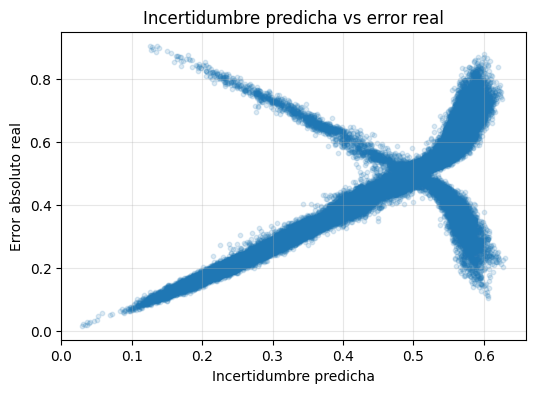

In [9]:
corr_err = np.corrcoef(
    results_test["uncertainty_hat"],
    results_test["error_abs_real"]
)[0, 1]

print(f"Correlacion entre incertidumbre predicha y error real absoluto: {corr_err:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(
    results_test["uncertainty_hat"],
    results_test["error_abs_real"],
    alpha=0.15,
    s=10
)
plt.title("Incertidumbre predicha vs error real")
plt.xlabel("Incertidumbre predicha")
plt.ylabel("Error absoluto real")
plt.grid(alpha=0.3)
plt.show()

# 9. Comparación de la distribución de incertidumbre por clase predicha

,count,mean,median,std
clase_predicha,,,,
Buen pagador,38465,0.337164,0.339295,0.090434
Mal pagador,23037,0.548806,0.550702,0.028623


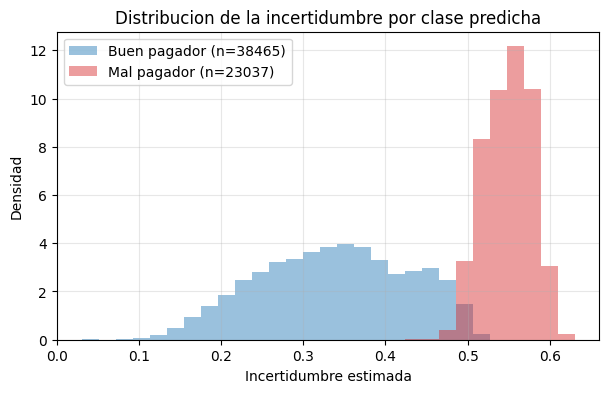

In [10]:
summary_unc = (
    results_test.groupby("clase_predicha")["uncertainty_hat"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)

display(summary_unc)

plt.figure(figsize=(7, 4))
unc_min = results_test["uncertainty_hat"].min()
unc_max = results_test["uncertainty_hat"].max()
if np.isclose(unc_min, unc_max):
    bins = np.linspace(unc_min - 1e-6, unc_max + 1e-6, 10)
else:
    bins = np.linspace(unc_min, unc_max, 30)

for clase, color in [("Buen pagador", "#1f77b4"), ("Mal pagador", "#d62728")]:
    values = results_test.loc[
        results_test["clase_predicha"] == clase,
        "uncertainty_hat",
    ]
    plt.hist(
        values,
        bins=bins,
        alpha=0.45,
        density=True,
        label=f"{clase} (n={len(values)})",
        color=color,
    )

plt.title("Distribucion de la incertidumbre por clase predicha")
plt.xlabel("Incertidumbre estimada")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 9.1 Reflexión sobre la incertidumbre y la calidad de `EXT_SOURCE`

Para responder a esta pregunta, se recuperan los flags originales de disponibilidad de `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` para cada observación del conjunto de test y se cruzan con `uncertainty_hat`. Se asume el orden de calidad `EXT_SOURCE_2 > EXT_SOURCE_3 > EXT_SOURCE_1`, por lo que una mayor `penalizacion_calidad` implica un perfil externo peor: faltan fuentes mejores y el modelo depende más de fuentes peores o de valores imputados.

,n,incertidumbre_media,incertidumbre_mediana,error_real_medio
perfil_fuentes,,,,
Ninguna (todo imputado),33,0.5948,0.5920,0.6446
EXT_SOURCE_1,10,0.5786,0.5846,0.6125
EXT_SOURCE_3,61,0.5415,0.5382,0.5830
EXT_SOURCE_3 + EXT_SOURCE_1,33,0.5360,0.5350,0.5489
EXT_SOURCE_2,7249,0.4663,0.4838,0.4679
EXT_SOURCE_2 + EXT_SOURCE_1,4946,0.4346,0.4549,0.4324
EXT_SOURCE_2 + EXT_SOURCE_3,27260,0.4134,0.4171,0.4095
EXT_SOURCE_2 + EXT_SOURCE_3 + EXT_SOURCE_1,21910,0.3987,0.3902,0.3947


,penalizacion_calidad,n,incertidumbre_media,error_real_medio
0,0,21910,0.3987,0.3947
1,1,27260,0.4134,0.4095
2,2,4946,0.4346,0.4324
3,3,7282,0.4666,0.4682
4,4,61,0.5415,0.5830
5,5,10,0.5786,0.6125
6,6,33,0.5948,0.6446


Correlacion penalizacion_calidad vs incertidumbre: 0.1691
Correlacion n_ext_disponibles vs incertidumbre: -0.1530


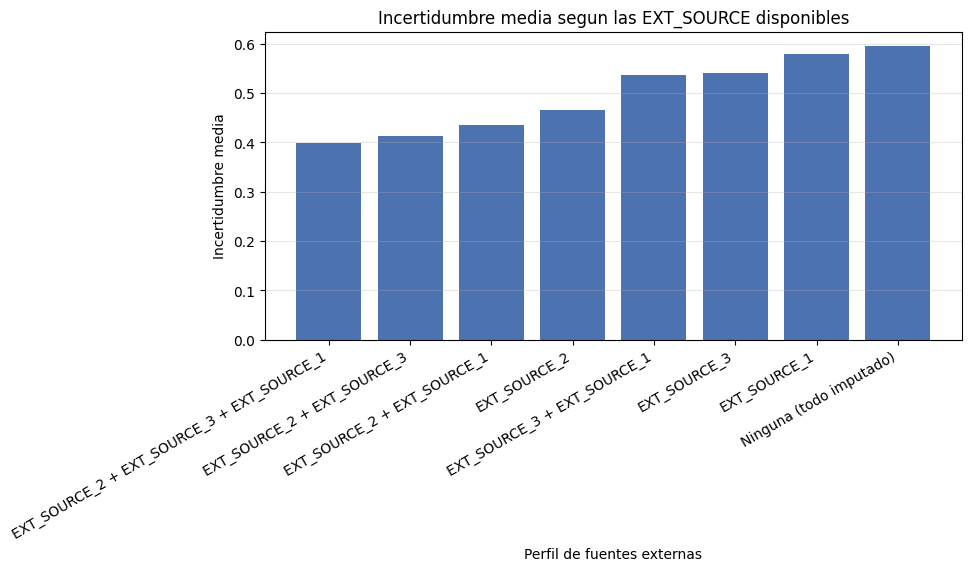

In [11]:
cols_ext = [
    "TARGET",
    "CODE_GENDER",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

df_ext = pd.read_csv(DATA_PATH, usecols=cols_ext)
df_ext = df_ext[df_ext["CODE_GENDER"].isin(["M", "F"])].copy()
df_ext["CODE_GENDER"] = df_ext["CODE_GENDER"].map({"M": 0, "F": 1})
df_ext["DAYS_BIRTH"] = df_ext["DAYS_BIRTH"].abs() / 365

for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    df_ext[col + "_NULL"] = df_ext[col].isnull().astype(int)
    df_ext[col] = df_ext[col].fillna(df_ext[col].median())

df_ext["AMT_ANNUITY"] = df_ext["AMT_ANNUITY"].fillna(df_ext["AMT_ANNUITY"].median())

X_full_ext = df_ext.drop(columns=["TARGET"])
y_full_ext = df_ext["TARGET"]
s_full_ext = df_ext["CODE_GENDER"]

_, X_test_ext, _, y_test_ext, _, _ = train_test_split(
    X_full_ext,
    y_full_ext,
    s_full_ext,
    test_size=0.2,
    random_state=SEED,
    stratify=y_full_ext,
)

assert np.array_equal(np.asarray(y_test_ext).astype(int), np.asarray(y_test).astype(int))

ext_unc = pd.concat(
    [
        results_test.reset_index(drop=True),
        X_test_ext[["EXT_SOURCE_1_NULL", "EXT_SOURCE_2_NULL", "EXT_SOURCE_3_NULL"]].reset_index(drop=True),
    ],
    axis=1,
)

for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    ext_unc[col + "_OBS"] = 1 - ext_unc[col + "_NULL"]

ext_unc["n_ext_disponibles"] = ext_unc[
    ["EXT_SOURCE_1_OBS", "EXT_SOURCE_2_OBS", "EXT_SOURCE_3_OBS"]
].sum(axis=1)

ext_unc["penalizacion_calidad"] = (
    3 * ext_unc["EXT_SOURCE_2_NULL"]
    + 2 * ext_unc["EXT_SOURCE_3_NULL"]
    + 1 * ext_unc["EXT_SOURCE_1_NULL"]
)

def perfil_ext(row):
    fuentes = []
    if row["EXT_SOURCE_2_OBS"] == 1:
        fuentes.append("EXT_SOURCE_2")
    if row["EXT_SOURCE_3_OBS"] == 1:
        fuentes.append("EXT_SOURCE_3")
    if row["EXT_SOURCE_1_OBS"] == 1:
        fuentes.append("EXT_SOURCE_1")
    return " + ".join(fuentes) if fuentes else "Ninguna (todo imputado)"

ext_unc["perfil_fuentes"] = ext_unc.apply(perfil_ext, axis=1)

summary_ext = (
    ext_unc.groupby("perfil_fuentes")
    .agg(
        n=("uncertainty_hat", "size"),
        incertidumbre_media=("uncertainty_hat", "mean"),
        incertidumbre_mediana=("uncertainty_hat", "median"),
        error_real_medio=("error_abs_real", "mean"),
    )
    .sort_values(["incertidumbre_media", "n"], ascending=[False, False])
)

display(summary_ext.round(4))

summary_pen = (
    ext_unc.groupby("penalizacion_calidad")
    .agg(
        n=("uncertainty_hat", "size"),
        incertidumbre_media=("uncertainty_hat", "mean"),
        error_real_medio=("error_abs_real", "mean"),
    )
    .reset_index()
    .sort_values("penalizacion_calidad")
)

display(summary_pen.round(4))

corr_pen = ext_unc["penalizacion_calidad"].corr(ext_unc["uncertainty_hat"])
corr_n = ext_unc["n_ext_disponibles"].corr(ext_unc["uncertainty_hat"])

print(f"Correlacion penalizacion_calidad vs incertidumbre: {corr_pen:.4f}")
print(f"Correlacion n_ext_disponibles vs incertidumbre: {corr_n:.4f}")

perfil_order = [
    "EXT_SOURCE_2 + EXT_SOURCE_3 + EXT_SOURCE_1",
    "EXT_SOURCE_2 + EXT_SOURCE_3",
    "EXT_SOURCE_2 + EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3 + EXT_SOURCE_1",
    "EXT_SOURCE_3",
    "EXT_SOURCE_1",
    "Ninguna (todo imputado)",
]

plot_ext = summary_ext.reindex([p for p in perfil_order if p in summary_ext.index])

plt.figure(figsize=(9, 4))
plt.bar(plot_ext.index, plot_ext["incertidumbre_media"], color="#4c72b0")
plt.title("Incertidumbre media segun las EXT_SOURCE disponibles")
plt.xlabel("Perfil de fuentes externas")
plt.ylabel("Incertidumbre media")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 10. Conclusión 

El enfoque de incertidumbre implementado sigue la idea explicada en clase: se entrena un **modelo principal FAIR** para predecir la probabilidad de impago y, posteriormente, un **modelo auxiliar** que aprende a estimar el **error absoluto** cometido por ese modelo principal. De este modo, la predicción final sobre el conjunto de test devuelve no solo la **clase predicha**, sino también una **medida de incertidumbre** asociada.

Los resultados muestran que la incertidumbre estimada está **fuertemente relacionada con el error real** de predicción. En particular, la correlación entre la incertidumbre predicha y el error absoluto real es alta, lo que indica que el modelo auxiliar es capaz de identificar con bastante precisión qué observaciones son más dudosas o menos fiables.

Además, se incorpora una comparación visual de la distribución de `uncertainty_hat` entre usuarios clasificados como **"Buen pagador"** y **"Mal pagador"**, lo que permite analizar si alguna de las dos clases concentra predicciones más inciertas. En los resultados obtenidos, las observaciones clasificadas como **"Mal pagador"** presentan, en promedio, una incertidumbre claramente más alta que las clasificadas como **"Buen pagador"**. Por tanto, puede concluirse que, cuando el modelo predice la clase **"Mal pagador"**, esa decisión tiende a ser menos fiable y más difícil que en el caso de las predicciones de **"Buen pagador"**.

Además, este esquema permite una interpretación útil en el contexto del problema: las solicitudes con **mayor incertidumbre** pueden tratarse como casos que requieren una **revisión adicional** o una validación humana antes de tomar una decisión final. Por tanto, el sistema no solo predice, sino que también informa sobre **cuánta confianza** merece cada predicción, cumpliendo así el objetivo del apartado de incertidumbre.